In [1]:
!git clone https://github.com/Oscosc/Projet-VO-2026.git

Cloning into 'Projet-VO-2026'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 149 (delta 7), reused 18 (delta 1), pack-reused 121 (from 1)
Receiving objects: 100% (149/149), 58.85 MiB | 13.07 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Updating files: 100% (81/81), done.


In [2]:
import os

source_dir = '/content/Projet-VO-2026/'
dest_dir = '/content/'

# Move all files and directories from source to destination
for item in os.listdir(source_dir):
    os.rename(os.path.join(source_dir, item), os.path.join(dest_dir, item))

# Remove the now empty source directory
os.rmdir(source_dir)

print(f"Contents of {source_dir} moved to {dest_dir} and {source_dir} removed.")


Contents of /content/Projet-VO-2026/ moved to /content/ and /content/Projet-VO-2026/ removed.


In [ ]:
!ls -a /content/

.	 datasets		    .git	sample_data
..	 Dense_corresponding.ipynb  .gitignore	weyl.py
.config  documents		    README.md	Weyl_test.ipynb


In [ ]:
#%load_ext autoreload
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import cv2

import weyl

In [ ]:
base_image = cv2.imread('datasets/tests_images/tree.png', cv2.IMREAD_GRAYSCALE) / 255.0
base_image = cv2.resize(base_image, dsize=(128, 128), interpolation=cv2.INTER_CUBIC)

part_image = base_image[54:85, 54:85]

np.random.seed(42)
noised_image = np.random.normal(base_image, 0.2)

Text(0.5, 1.0, 'Noised image')

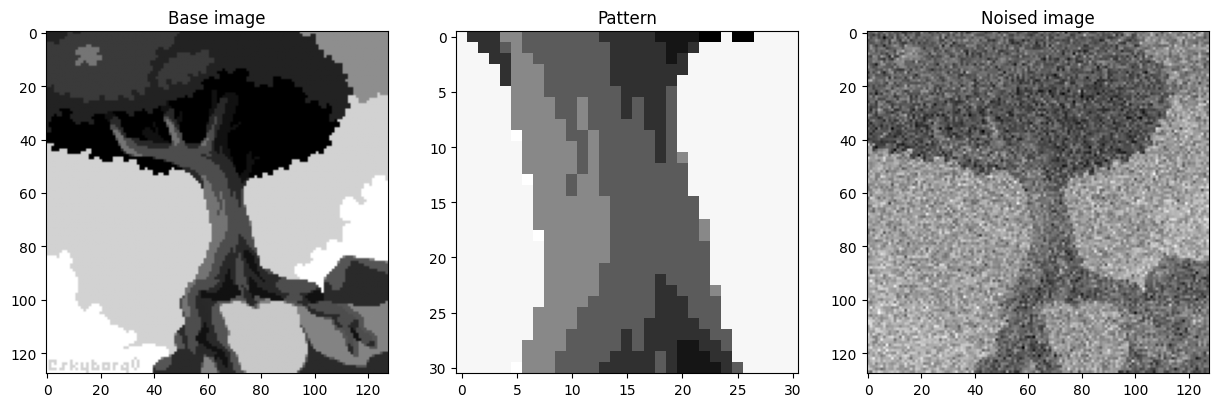

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 15))

ax1.imshow(base_image, cmap='gray')
ax1.set_title("Base image")

ax2.imshow(part_image, cmap='gray')
ax2.set_title("Pattern")

ax3.imshow(noised_image, cmap='gray')
ax3.set_title("Noised image")

100%|██████████| 128/128 [01:23<00:00,  1.54it/s]

------------------------------------------------------------------
Total execution time        : 83.35944485664368 seconds
Average row execution time  : 0.6512456629425287 seconds
Average cell execution time : 0.005087856741738506 seconds
------------------------------------------------------------------
Found at position : (np.int64(69), np.int64(69))


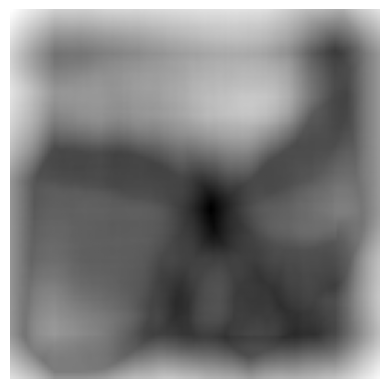

In [ ]:
diff_image_optimized, (px, py) = weyl.PatternMatching(part_image, noised_image, weyl.WeylOptimized)
print(f"Found at position : {px, py}")
plt.axis('off')
plt.imshow(diff_image_optimized, cmap='gray')
plt.show()

100%|██████████| 128/128 [05:39<00:00,  2.65s/it]

------------------------------------------------------------------
Total execution time        : 339.81341791152954 seconds
Average row execution time  : 2.6547923274338245 seconds
Average cell execution time : 0.020740565058076754 seconds
------------------------------------------------------------------


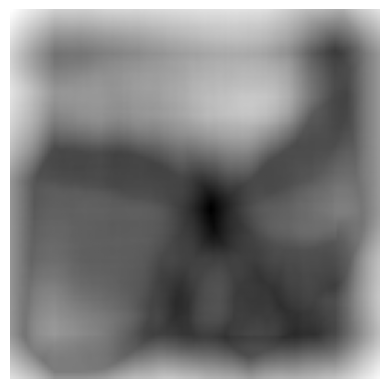

In [ ]:
diff_image_naive, _ = weyl.PatternMatching(part_image, noised_image, weyl.WeylNaive)
plt.axis('off')
plt.imshow(diff_image_naive, cmap='gray')
plt.show()

In [ ]:
models_variation = diff_image_naive - diff_image_optimized

reconstructed_image = base_image.copy()
reconstructed_image[54:85, 54:85] = 0.0
reconstructed_image[px - 15:px + 15 + 1, py - 15:py + 15 + 1] = part_image

delta_image = base_image - reconstructed_image

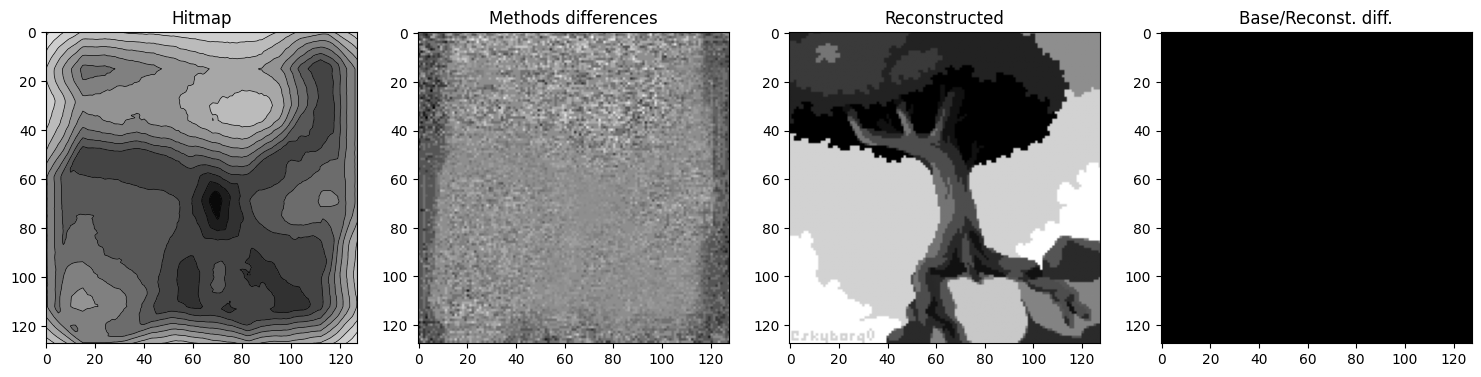

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 15))

ax1.contourf(diff_image_optimized, levels=12, cmap='gray')
ax1.contour(diff_image_optimized, levels=12, colors='black', linewidths=0.5)
ax1.set_aspect('equal')
ax1.invert_yaxis()
ax1.set_title("Hitmap")

ax2.imshow(models_variation, cmap='gray')
ax2.set_title("Methods differences")

ax3.imshow(reconstructed_image, cmap='gray')
ax3.set_title("Reconstructed")

ax4.imshow(delta_image, cmap='gray')
ax4.set_title("Base/Reconst. diff.")

plt.tight_layout()
plt.show()

#Essais

In [ ]:
!unzip /content/Scenario1AudioAnnotations.zip
!unzip /content/Scenario1LowRes.zip

Archive:  /content/Scenario1AudioAnnotations.zip
   creating: annot_scenario1/
  inflating: annot_scenario1/F1C1.txt  
  inflating: annot_scenario1/F1C10.txt  
  inflating: annot_scenario1/F1C11.txt  
  inflating: annot_scenario1/F1C12.txt  
  inflating: annot_scenario1/F1C13.txt  
  inflating: annot_scenario1/F1C14.txt  
  inflating: annot_scenario1/F1C15.txt  
  inflating: annot_scenario1/F1C16.txt  
  inflating: annot_scenario1/F1C17.txt  
  inflating: annot_scenario1/F1C18.txt  
  inflating: annot_scenario1/F1C19.txt  
  inflating: annot_scenario1/F1C2.txt  
  inflating: annot_scenario1/F1C20.txt  
  inflating: annot_scenario1/F1C21.txt  
  inflating: annot_scenario1/F1C22.txt  
  inflating: annot_scenario1/F1C23.txt  
  inflating: annot_scenario1/F1C24.txt  
  inflating: annot_scenario1/F1C25.txt  
  inflating: annot_scenario1/F1C4.txt  
  inflating: annot_scenario1/F1C5.txt  
  inflating: annot_scenario1/F1C6.txt  
  inflating: annot_scenario1/F1C7.txt  
  inflating: annot_scenar

In [4]:
!ffmpeg -y -ss 00:00:00 -i "F1C1LR.mp4" -t 10 -c:v libx264 -c:a aac "extrait_video_personne.mp4"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

✅ Vidéo lue avec succès. Résolution de l'image : 640 pixels de large x 360 pixels de haut.
✏️ Dessin du rectangle vert aux coordonnées : x=330, y=100, largeur=40, hauteur=50


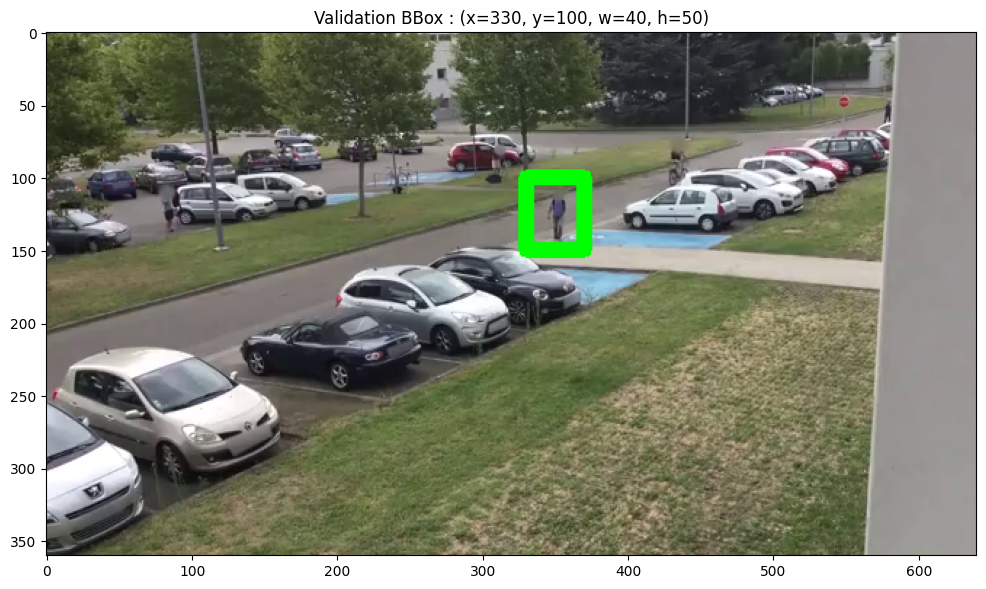

In [ ]:
import cv2
import matplotlib.pyplot as plt

def show_first_frame(video_path, bbox=None):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if ret:
        print(f"✅ Vidéo lue avec succès. Résolution de l'image : {frame.shape[1]} pixels de large x {frame.shape[0]} pixels de haut.")

        if bbox is not None:
            # On force les coordonnées en entiers
            x, y, w, h = map(int, bbox)
            print(f"✏️ Dessin du rectangle vert aux coordonnées : x={x}, y={y}, largeur={w}, hauteur={h}")

            # On dessine avec une épaisseur très large (10 au lieu de 3)
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 10)
        else:
            print("⚠️ Aucune Bounding Box n'a été fournie à la fonction.")

        # Colab/Matplotlib utilise RGB, OpenCV utilise BGR
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 8))
        plt.imshow(frame_rgb)

        if bbox is not None:
            plt.title(f"Validation BBox : (x={x}, y={y}, w={w}, h={h})")

        plt.axis('on')
        plt.show()
    else:
        print("❌ Erreur : Impossible de lire la vidéo.")

# --- Utilisation ---
ma_bbox = ma_bbox = (330, 100, 40, 50)
show_first_frame("F1C1LR.mp4", bbox=ma_bbox)

In [ ]:
import cv2
import numpy as np

def FastWeylOptimized(image_in):
    """Version Vectorisée et Ultra-Rapide de la Discrépance de Weyl"""

    # 1. Image intégrale calculée en C++ par OpenCV (Instantané)
    # L'indexation [1:, 1:] permet d'enlever la ligne/colonne de zéros ajoutée par OpenCV
    I0 = cv2.integral(image_in, sdepth=cv2.CV_32F)[1:, 1:]

    # 2. Opérations vectorielles NumPy (Suppression totale des boucles for)
    I0_x_cols = I0[:, -1:]  # Dernière colonne isolée
    I0_rows_y = I0[-1:, :]  # Dernière ligne isolée

    I1 = I0_x_cols - I0
    I2 = I0_rows_y - I0
    I3 = I0 - I0_rows_y - I0_x_cols

    # 3. Corrections des cas spécifiques sur les bords
    I1[:, -1] = I0[:, -1]
    I2[-1, :] = I0[-1, :]
    I3[-1, :-1] = -I0[-1, :-1]
    I3[:-1, -1] = -I0[:-1, -1]
    I3[-1, -1] = 0

    # 4. Calcul des minimums et maximums directs
    mins = np.minimum(0, [I0.min(), I1.min(), I2.min(), I3.min()])
    maxs = np.maximum(0, [I0.max(), I1.max(), I2.max(), I3.max()])

    return np.max(maxs - mins)

In [7]:
import cv2
import numpy as np

def FastWeylOptimized(image_in):
    """Version Vectorisée et Ultra-Rapide de la Discrépance de Weyl"""

    # 1. Image intégrale calculée en C++ par OpenCV (Instantané)
    I0 = cv2.integral(image_in, sdepth=cv2.CV_32F)[1:, 1:]

    # 2. Opérations vectorielles NumPy (Suppression totale des boucles for)
    I0_x_cols = I0[:, -1:]
    I0_rows_y = I0[-1:, :]

    I1 = I0_x_cols - I0
    I2 = I0_rows_y - I0
    I3 = I0 - I0_rows_y - I0_x_cols

    # 3. Corrections des cas spécifiques sur les bords
    I1[:, -1] = I0[:, -1]
    I2[-1, :] = I0[-1, :]
    I3[-1, :-1] = -I0[-1, :-1]
    I3[:-1, -1] = -I0[:-1, -1]
    I3[-1, -1] = 0

    # 4. Calcul des minimums et maximums directs
    mins = np.minimum(0, [I0.min(), I1.min(), I2.min(), I3.min()])
    maxs = np.maximum(0, [I0.max(), I1.max(), I2.max(), I3.max()])

    return np.max(maxs - mins)

def PatternMatching_Fixed(pattern, image_in, WeylsFunction):
    """Version corrigée du PatternMatching pour régler le padding et le drift."""
    nx, ny = image_in.shape
    px, py = pattern.shape

    # Correction : px est la hauteur, py est la largeur
    padx, pady = px // 2, py // 2

    # Ordre OpenCV: src, top, bottom, left, right
    image_w_borders = cv2.copyMakeBorder(image_in, padx, padx, pady, pady, cv2.BORDER_CONSTANT, value=0.0)

    image_out = np.zeros((nx, ny))

    # Recherche du motif
    for i in range(nx):
        for j in range(ny):
            zone = image_w_borders[i:i+px, j:j+py]
            diff = zone - pattern
            image_out[i, j] = WeylsFunction(diff)

    # Position du minimum
    position = np.unravel_index(image_out.argmin(), image_out.shape)
    return image_out, position

def track_video_colab(video_path, output_path, init_bbox, padding=40, max_frames=None):
    x, y, w, h = init_bbox

    cap = cv2.VideoCapture(video_path)

    # 1. Lire la première frame
    ret, frame = cap.read()
    if not ret:
        print("Erreur : Impossible de lire la vidéo.")
        return

    img_h_full, img_w_full = frame.shape[:2]
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (img_w_full, img_h_full))

    # Initialisation du motif de référence (fixe)
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    pattern = gray_frame[y:y+h, x:x+w]

    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    out.write(frame)

    print(f"Dimensions de la vidéo : {img_w_full}x{img_h_full}")

    if max_frames is not None:
        print(f"Traitement limité à {max_frames} images...")
    else:
        print("Traitement de la vidéo entière en cours...")

    frame_count = 1

    while True:
        # Condition d'arrêt optionnelle
        if max_frames is not None and frame_count >= max_frames:
            print(f"Limite de {max_frames} images atteinte. Arrêt propre du traitement.")
            break

        ret, frame = cap.read()
        if not ret:
            print("Fin de la vidéo atteinte. Traitement complet réussi !")
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)

        # Sécurisation de la zone de recherche
        roi_x1 = max(0, x - padding)
        roi_y1 = max(0, y - padding)
        roi_x2 = min(img_w_full, x + w + padding)
        roi_y2 = min(img_h_full, y + h + padding)

        roi = gray_frame[roi_y1:roi_y2, roi_x1:roi_x2]

        # Sécurité anti-crash si l'objet sort de l'écran
        if roi.shape[0] == 0 or roi.shape[1] == 0:
            print(f"L'objet est sorti de l'écran à l'image {frame_count}. Fin du tracking.")
            break

        # Appel de la fonction de matching
        _, local_pos = PatternMatching_Fixed(pattern, roi, FastWeylOptimized)

        # Correction de la dérive (Drift)
        px_pattern, py_pattern = pattern.shape
        y = roi_y1 + local_pos[0] - (px_pattern // 2)
        x = roi_x1 + local_pos[1] - (py_pattern // 2)

        # (La mise à jour du template a été retirée pour profiter de la robustesse de Weyl)

        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        out.write(frame)

        frame_count += 1
        if frame_count % 10 == 0:
            print(f"{frame_count} images traitées...")

    cap.release()
    out.release()
    print(f"Tracking terminé ! Vidéo sauvegardée sous : {output_path}")

# --- UTILISATION ---
# Remplace par ta vidéo coupée et tes coordonnées exactes
ma_bbox = (340, 110, 20, 40)

# Lance le suivi sur toute la vidéo
track_video_colab("extrait_video_personne.mp4", "resultat_weyl.mp4", ma_bbox, padding=2000)

Dimensions de la vidéo : 640x360
Traitement de la vidéo entière en cours...


KeyboardInterrupt: 

In [8]:
import cv2
import numpy as np

def track_video_colab(video_path, output_path, init_bbox, padding=40, max_frames=None):
    x, y, w, h = init_bbox

    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    if not ret:
        print("Erreur : Impossible de lire la vidéo.")
        return

    img_h_full, img_w_full = frame.shape[:2]
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    # 1. VideoWriter original (Tracking)
    out = cv2.VideoWriter(output_path, fourcc, fps, (img_w_full, img_h_full))

    # 2. NOUVEAU VideoWriter pour la Heatmap
    output_heatmap_path = output_path.replace(".mp4", "_heatmap.mp4")
    out_heatmap = cv2.VideoWriter(output_heatmap_path, fourcc, fps, (img_w_full, img_h_full))

    # Initialisation
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    pattern = gray_frame[y:y+h, x:x+w]

    # Écriture de la première frame pour la vidéo classique
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    out.write(frame)

    # Pour la première frame de la heatmap, on met un fond noir
    out_heatmap.write(np.zeros((img_h_full, img_w_full, 3), dtype=np.uint8))

    print(f"Création de la vidéo de Tracking : {output_path}")
    print(f"Création de la vidéo de Disparité : {output_heatmap_path}")

    frame_count = 1

    while True:
        if max_frames is not None and frame_count >= max_frames:
            break

        ret, frame = cap.read()
        if not ret:
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)

        roi_x1 = max(0, x - padding)
        roi_y1 = max(0, y - padding)
        roi_x2 = min(img_w_full, x + w + padding)
        roi_y2 = min(img_h_full, y + h + padding)

        roi = gray_frame[roi_y1:roi_y2, roi_x1:roi_x2]

        if roi.shape[0] == 0 or roi.shape[1] == 0:
            break

        # Appel de la fonction de matching (on récupère image_out qui est la carte des dissemblances)
        image_out, local_pos = PatternMatching_Fixed(pattern, roi, FastWeylOptimized)

        # =========================================================
        # CRÉATION DE LA CARTE DE CHALEUR (HEATMAP)
        # 1. On crée une image noire de la taille de la vidéo
        heatmap_frame = np.zeros((img_h_full, img_w_full), dtype=np.uint8)

        # 2. On normalise les valeurs de Weyl entre 0 et 255
        disp_norm = cv2.normalize(image_out, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

        # 3. On place cette petite carte normalisée au bon endroit sur l'image noire
        heatmap_frame[roi_y1:roi_y2, roi_x1:roi_x2] = disp_norm

        # 4. On applique de la couleur (Bleu = Match parfait, Rouge = Très différent)
        heatmap_color = cv2.applyColorMap(heatmap_frame, cv2.COLORMAP_JET)

        # 5. On dessine aussi le carré vert sur la heatmap pour repérer le minimum !
        # =========================================================

        # Correction de la dérive (Drift)
        px_pattern, py_pattern = pattern.shape
        y = roi_y1 + local_pos[0] - (px_pattern // 2)
        x = roi_x1 + local_pos[1] - (py_pattern // 2)

        # Dessin sur la vidéo normale
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        out.write(frame)

        # Dessin sur la vidéo heatmap
        cv2.rectangle(heatmap_color, (x, y), (x + w, y + h), (0, 255, 0), 2)
        out_heatmap.write(heatmap_color)

        frame_count += 1
        if frame_count % 10 == 0:
            print(f"{frame_count} images traitées...")

    cap.release()
    out.release()
    out_heatmap.release()
    print("Tracking terminé ! Les deux vidéos ont été sauvegardées.")

# --- UTILISATION ---
ma_bbox = (340, 110, 20, 40)
track_video_colab("extrait_video_personne.mp4", "resultat_weyl.mp4", ma_bbox, padding=2000)

Création de la vidéo de Tracking : resultat_weyl.mp4
Création de la vidéo de Disparité : resultat_weyl_heatmap.mp4
10 images traitées...
20 images traitées...
30 images traitées...
40 images traitées...
50 images traitées...
60 images traitées...
70 images traitées...
80 images traitées...
90 images traitées...
100 images traitées...
110 images traitées...
120 images traitées...
130 images traitées...
140 images traitées...
150 images traitées...
160 images traitées...
170 images traitées...
180 images traitées...
190 images traitées...
200 images traitées...
210 images traitées...
220 images traitées...
230 images traitées...
240 images traitées...
250 images traitées...
260 images traitées...
270 images traitées...
280 images traitées...
290 images traitées...
300 images traitées...
Tracking terminé ! Les deux vidéos ont été sauvegardées.
